### NARX data interpretation

In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# lag order for NARX regressor
lag = 5

# model settings
out_dim = 1
units = 32
n_epochs = 150
bs = 64
tol = 5
no_improve = 0

# Load data 
data = np.load(
    "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files/training-val-test-data.npz"
)
y_raw = data["th"]
u_raw = data["u"]


def build_regressor_matrix(u, y, p):
    # stack lagged inputs and outputs into rows
    # each row: [u(k-p)...u(k-1), y(k-p)...y(k-1)] -> y(k)
    phi, targets = [], []
    for k in range(p, len(y)):
        phi.append(np.concatenate([u[k-p:k], y[k-p:k]]))
        targets.append(y[k])
    return np.array(phi), np.array(targets)

### Normalize data

In [2]:
# split and normalize 
phi, targets = build_regressor_matrix(u_raw, y_raw, lag)

# last 30% as test set, no shuffle to keep time order
phi_tv, phi_test, t_tv, t_test = train_test_split(
    phi, targets, test_size=0.3, random_state=24, shuffle=False
)
phi_train, phi_val, t_train, t_val = train_test_split(
    phi_tv, t_tv, test_size=0.35, random_state=24, shuffle=True
)

# normalise using train stats only
x_mu  = phi_train.mean(axis=0)
x_sig = phi_train.std(axis=0)
y_mu  = t_train.mean()
y_sig = t_train.std()

phi_train = (phi_train - x_mu) / x_sig
phi_val   = (phi_val - x_mu) / x_sig
phi_test  = (phi_test - x_mu) / x_sig
t_train   = (t_train - y_mu) / y_sig
t_val     = (t_val - y_mu) / y_sig
t_test    = (t_test - y_mu) / y_sig

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
phi_train, phi_val, phi_test = to_t(phi_train), to_t(phi_val), to_t(phi_test)
t_train,   t_val, t_test   = to_t(t_train), to_t(t_val), to_t(t_test)

input_size = phi_train.shape[1]

### simple neural network structure

In [3]:
# structure of the simple MLP model
class MLP(nn.Module):
    def __init__(self, n_in, n_out, n_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden).float()
        self.fc2 = nn.Linear(n_hidden, n_hidden).float()
        self.fc3 = nn.Linear(n_hidden, n_out).float()

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return self.fc3(x)[:, 0]

model = MLP(input_size, out_dim, units)
# Adam optimizer usually the best choice
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn  = nn.MSELoss()

### training loop for the simple NN model. Using the normalized NARX data

In [4]:
idx = np.arange(len(phi_train), dtype=int)
best_val   = float("inf")
best_state = None
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    np.random.shuffle(idx)

    model.train()
    for i in range(0, len(phi_train), bs):
        batch = idx[i:i+bs]
        pred = model(phi_train[batch])
        loss = loss_fn(pred, t_train[batch])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        model.eval()
        v_rmse = loss_fn(model(phi_val),   t_val).sqrt()
        t_rmse = loss_fn(model(phi_train), t_train).sqrt()

    print(f"epoch {epoch}  train {t_rmse:.4f}  val {v_rmse:.4f}")

    if v_rmse < best_val:
        best_val = v_rmse
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1

    if no_improve >= tol:
        print(f"early stop at epoch {epoch}, best val {best_val:.4f}")
        break

    train_hist.append(t_rmse.item())
    val_hist.append(v_rmse.item())

model.load_state_dict(best_state)

epoch 0  train 0.4296  val 0.4395
epoch 1  train 0.1618  val 0.1688
epoch 2  train 0.1424  val 0.1488
epoch 3  train 0.1267  val 0.1325
epoch 4  train 0.1129  val 0.1183
epoch 5  train 0.1020  val 0.1069
epoch 6  train 0.0947  val 0.0994
epoch 7  train 0.0849  val 0.0892
epoch 8  train 0.0784  val 0.0823
epoch 9  train 0.0735  val 0.0771
epoch 10  train 0.0672  val 0.0705
epoch 11  train 0.0642  val 0.0671
epoch 12  train 0.0564  val 0.0591
epoch 13  train 0.0507  val 0.0532
epoch 14  train 0.0523  val 0.0542
epoch 15  train 0.0404  val 0.0425
epoch 16  train 0.0373  val 0.0390
epoch 17  train 0.0374  val 0.0387
epoch 18  train 0.0278  val 0.0293
epoch 19  train 0.0252  val 0.0265
epoch 20  train 0.0244  val 0.0256
epoch 21  train 0.0229  val 0.0238
epoch 22  train 0.0211  val 0.0221
epoch 23  train 0.0198  val 0.0209
epoch 24  train 0.0188  val 0.0199
epoch 25  train 0.0180  val 0.0190
epoch 26  train 0.0171  val 0.0182
epoch 27  train 0.0164  val 0.0173
epoch 28  train 0.0174  val 0.

<All keys matched successfully>

### Evuation of the model using test data split

RMS:  0.0050 rad  /  0.2841 deg
NRMS: 0.98%


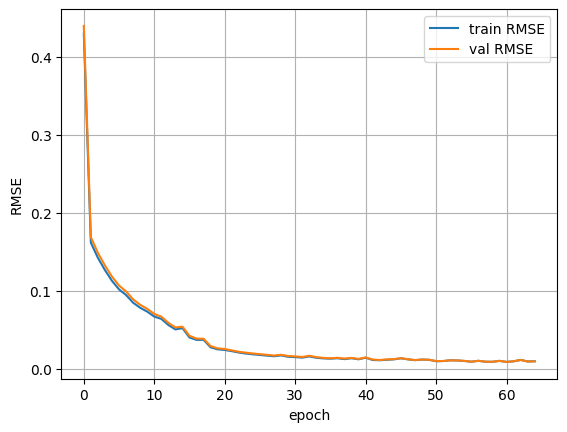

In [5]:
model.eval()
with torch.no_grad():
    pred_norm = model(phi_test).numpy()

# denormalise predictions and targets
pred_real = pred_norm * y_sig + y_mu
true_real = t_test.numpy() * y_sig + y_mu

rms = np.mean((pred_real - true_real)**2)**0.5
print(f"RMS:  {rms:.4f} rad  /  {rms/(2*np.pi)*360:.4f} deg")
print(f"NRMS: {rms/np.std(true_real)*100:.2f}%")

plt.plot(train_hist, label="train RMSE")
plt.plot(val_hist, label="val RMSE")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(); plt.show()

### simulation of the model to predict outcomes

sim RMS:  0.0847 rad  /  4.8540 deg
sim NRMS: 17.67%


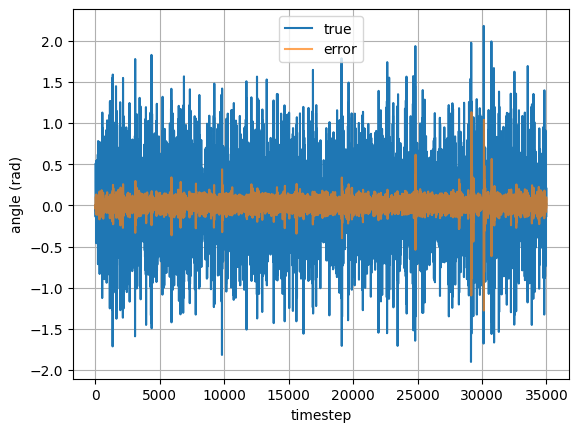

In [6]:
def simulate(f, u, y, skip=50, p=5, x_mu=None, x_sig=None, y_mu=None, y_sig=None):
    # use past values with ground truth during the burn in period
    upast = u[skip-p:skip].tolist()
    ypast = y[skip-p:skip].tolist()
    out   = y[:skip].tolist()

    f.eval()
    for k in range(skip, len(u)):
        x  = np.concatenate([upast, ypast])
        xt = torch.tensor((x - x_mu) / x_sig, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            yp = f(xt).item() * y_sig + y_mu
        out.append(yp)
        # append the buffers forward
        upast.append(u[k]); upast.pop(0)
        ypast.append(yp);   ypast.pop(0)

    return np.array(out)

sim = simulate(model, u_raw, y_raw, skip=lag, p=lag,
               x_mu=x_mu, x_sig=x_sig, y_mu=y_mu, y_sig=y_sig)

err     = sim[lag:] - y_raw[lag:]
rms_sim = np.mean(err**2)**0.5
print(f"sim RMS:  {rms_sim:.4f} rad  /  {rms_sim/(2*np.pi)*360:.4f} deg")
print(f"sim NRMS: {rms_sim/np.std(y_raw[lag:])*100:.2f}%")

plt.plot(y_raw, label="true")
plt.plot(sim - y_raw, label="error", alpha=0.7)
plt.xlabel("timestep"); plt.ylabel("angle (rad)"); plt.legend(); plt.grid(); plt.show()

### Prediction submission file (ANN)

In [7]:
# Load the hidden test prediction file
BENCHMARK_DIR = "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files"
pred_data   = np.load(f"{BENCHMARK_DIR}/hidden-test-prediction-submission-file.npz")
upast_test  = pred_data['upast']   # N x 15: u[k-15]...u[k-1]
thpast_test = pred_data['thpast']  # N x 15: y[k-15]...y[k-1]

# Take the last `lag` steps to match the training regressor shape (2*lag features)
Xtest = np.concatenate([upast_test[:, 15-lag:], thpast_test[:, 15-lag:]], axis=1)

# Normalize with training stats and run through the model
Xtest_norm = (Xtest - x_mu) / x_sig
Xtest_t    = torch.tensor(Xtest_norm, dtype=torch.float32)

model.eval()
with torch.no_grad():
    thnow = model(Xtest_t).numpy() * y_sig + y_mu

assert len(thnow) == len(upast_test), 'number of samples changed!'

np.savez(f"{BENCHMARK_DIR}/hidden-test-prediction-ANN-submission-file.npz",
         upast=upast_test, thpast=thpast_test, thnow=thnow)
print(f"Prediction submission saved: {len(thnow)} samples")

# also save as CSV: columns = [upast(15), thpast(15), thnow] — last col is thnow
np.savetxt(f"{BENCHMARK_DIR}/hidden-test-prediction-ANN-submission-file.csv",
           np.column_stack([upast_test, thpast_test, thnow]), delimiter=',')
print("Prediction CSV saved.")


Prediction submission saved: 645 samples


### Simulation submission file (ANN)

In [ ]:
# Load the hidden test simulation file
sim_data = np.load(f"{BENCHMARK_DIR}/hidden-test-simulation-submission-file.npz")
u_test   = sim_data['u']
th_test  = sim_data['th']  # first 50 values are real ground truth, rest are zeros

# Simulate with 50-step burn-in using the trained ANN model
th_test_sim = simulate(model, u_test, th_test, skip=50, p=lag,
                       x_mu=x_mu, x_sig=x_sig, y_mu=y_mu, y_sig=y_sig)

assert len(th_test_sim) == len(th_test), 'length mismatch!'

np.savez(f"{BENCHMARK_DIR}/hidden-test-simulation-ANN-submission-file.npz",
         th=th_test_sim, u=u_test)
print(f"Simulation submission saved: {len(th_test_sim)} samples")

# also save as CSV: columns = [u, th_sim], last col is th
np.savetxt(f"{BENCHMARK_DIR}/hidden-test-simulation-ANN-submission-file.csv",
           np.column_stack([u_test, th_test_sim]), delimiter=',')
print("Simulation CSV saved.")


Simulation submission saved: 5000 samples
